# **Analisis Pengaruh Tekanan Akademik terhadap Risiko Burnout Mahasiswa Menggunakan Algoritma Support Vector Machine dan Random Forest**

1. Putri Sofiyatus Salwa (24031554112) 

2. Adisti Eka Nabila (24031554119) 

3. Cintiya Agustin Nareswari (24031554218) 

Dataset: https://www.kaggle.com/datasets/sharmajicoder/student-mental-health-and-burnout

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.svm import LinearSVC

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    recall_score

)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import learning_curve

# **Load Data**

In [3]:
data = pd.read_csv(
    "student_mental_health_burnout_1M.csv"
)

display(data.head())

print("Shape:",data.shape)

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


Shape: (1000000, 20)


In [4]:
data.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,22.996456,2.500782,5.001727,5.998810,70.999135,4.246462,2.986413,1.274728,6.501713,3.011153,4.999724,5.018766,5.038116,5.002920,5.983287,1.784073,7.023073,1.324896
std,3.742579,1.117749,1.989340,1.548268,5.660073,1.678998,1.509844,1.221273,1.472972,1.463679,1.976536,1.960599,2.157838,1.976426,1.960972,1.664035,1.310698,1.342727
min,17.000000,1.000000,0.000000,1.000000,42.365714,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.309745,0.000000
25%,20.000000,2.000000,3.650644,4.944647,67.180912,3.102593,1.923747,0.005198,5.491047,1.990596,3.650029,3.651138,3.491114,3.656767,4.647065,0.124810,6.141553,0.000000
50%,23.000000,3.000000,4.998222,5.998906,70.999914,4.244029,2.969514,1.047839,6.501938,3.000619,4.999017,5.003518,5.001542,5.001279,5.999517,1.496505,7.074414,1.009531
75%,26.000000,4.000000,6.345532,7.051914,74.820937,5.385464,4.014996,2.086397,7.514642,4.011208,6.349751,6.351386,6.506834,6.354571,7.351578,2.889473,7.962169,2.173661
max,29.000000,4.000000,14.000000,10.000000,97.246309,10.000000,10.000000,8.530800,10.000000,7.000000,10.000000,12.000000,14.000000,10.000000,10.000000,10.000000,10.000000,9.326226


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [6]:
data.isnull().sum()

age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_score           0
mental_health_index     0
risk_level              0
dropout_risk            0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
print("\nUNIQUE")

print("Gender :", data["gender"].unique())
print("Academic Year :", data["academic_year"].unique())
print("Risk Level :", data["risk_level"].unique())


UNIQUE
Gender : ['Male' 'Female' 'Other']
Academic Year : [2 3 4 1]
Risk Level : ['Low' 'High' 'Medium']


# **EDA**

## **Distribusi Target**

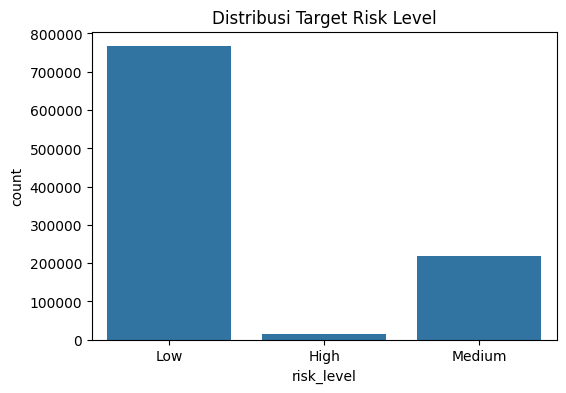

In [9]:
data["risk_level"].value_counts()

data["risk_level"].value_counts(normalize=True)*100

plt.figure(figsize=(6,4))
sns.countplot(x='risk_level', data=data)
plt.title("Distribusi Target Risk Level")
plt.show()

## **Distribusi Data Kategorikal**

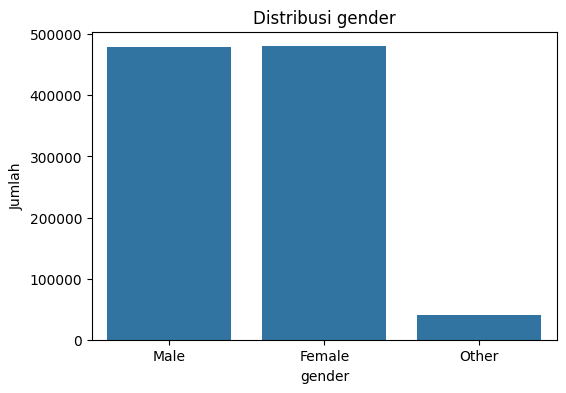

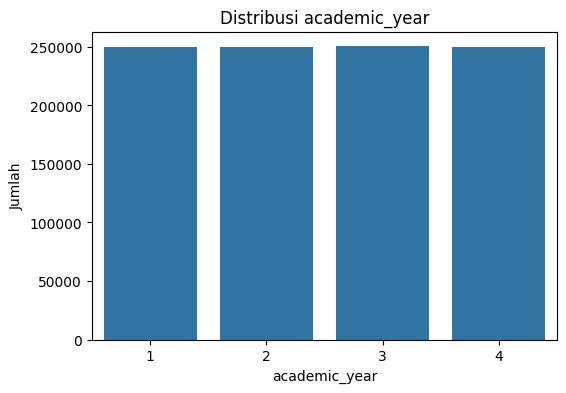

In [10]:
categorical_eda = [
    "gender",
    "academic_year"
]

for col in categorical_eda:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=col,
        data=data
    )

    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Jumlah")

    plt.show()

## **Analisis distribusi Fitur Numerik**

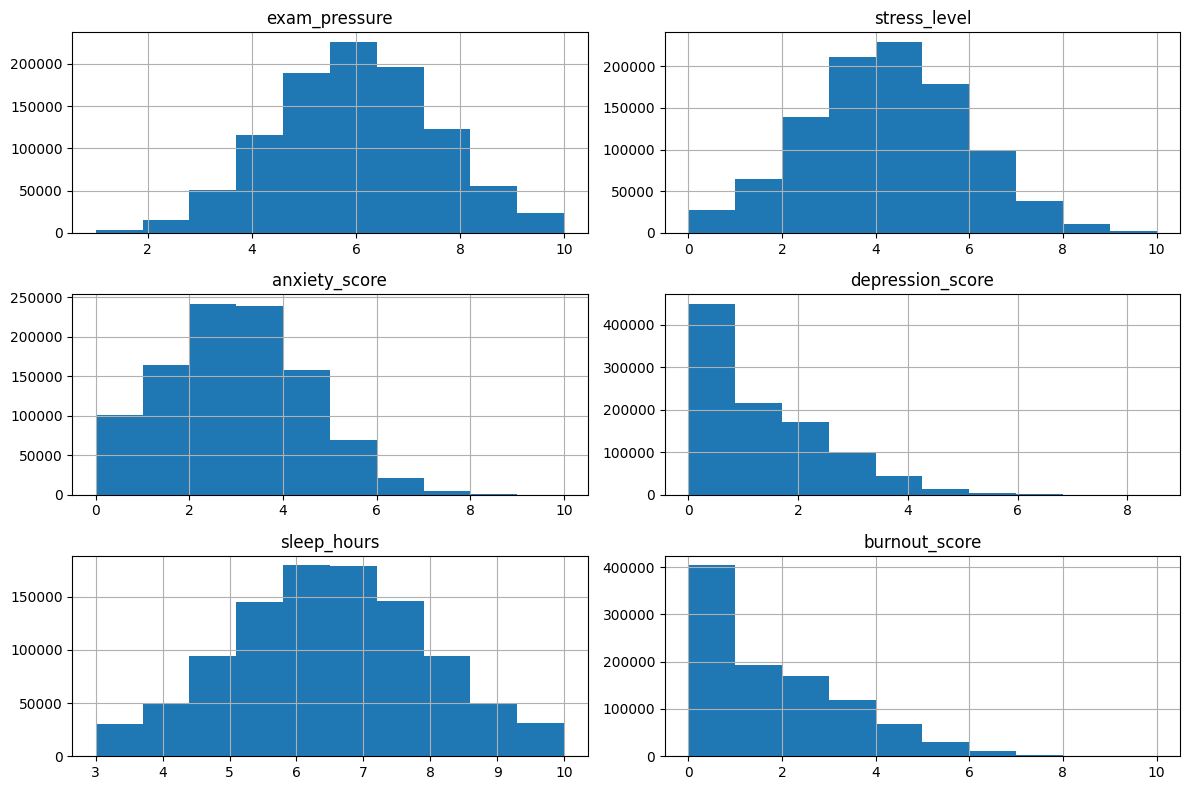

In [11]:
numerical_eda=['exam_pressure', 'stress_level','anxiety_score', 'depression_score', 'sleep_hours','burnout_score']

data[numerical_eda].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

## **Deteksi Outlier**

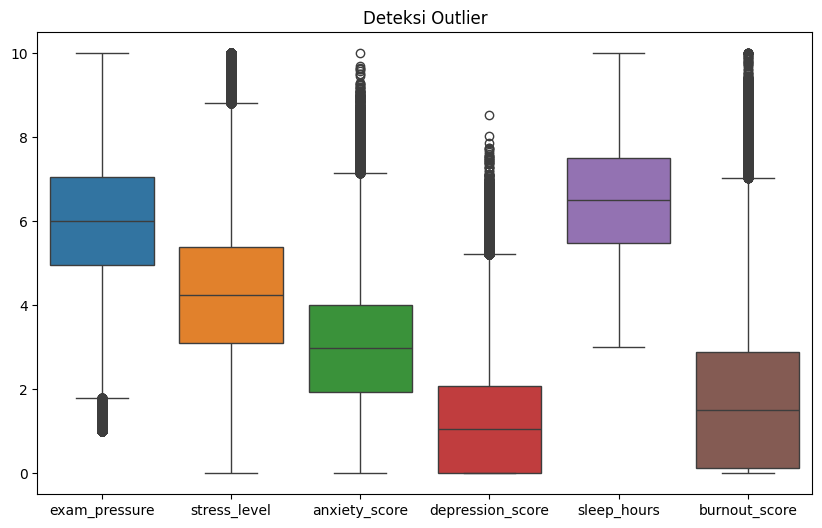

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data[numerical_eda])
plt.title("Deteksi Outlier")
plt.show()

## **Analisis Korelasi Fitur**

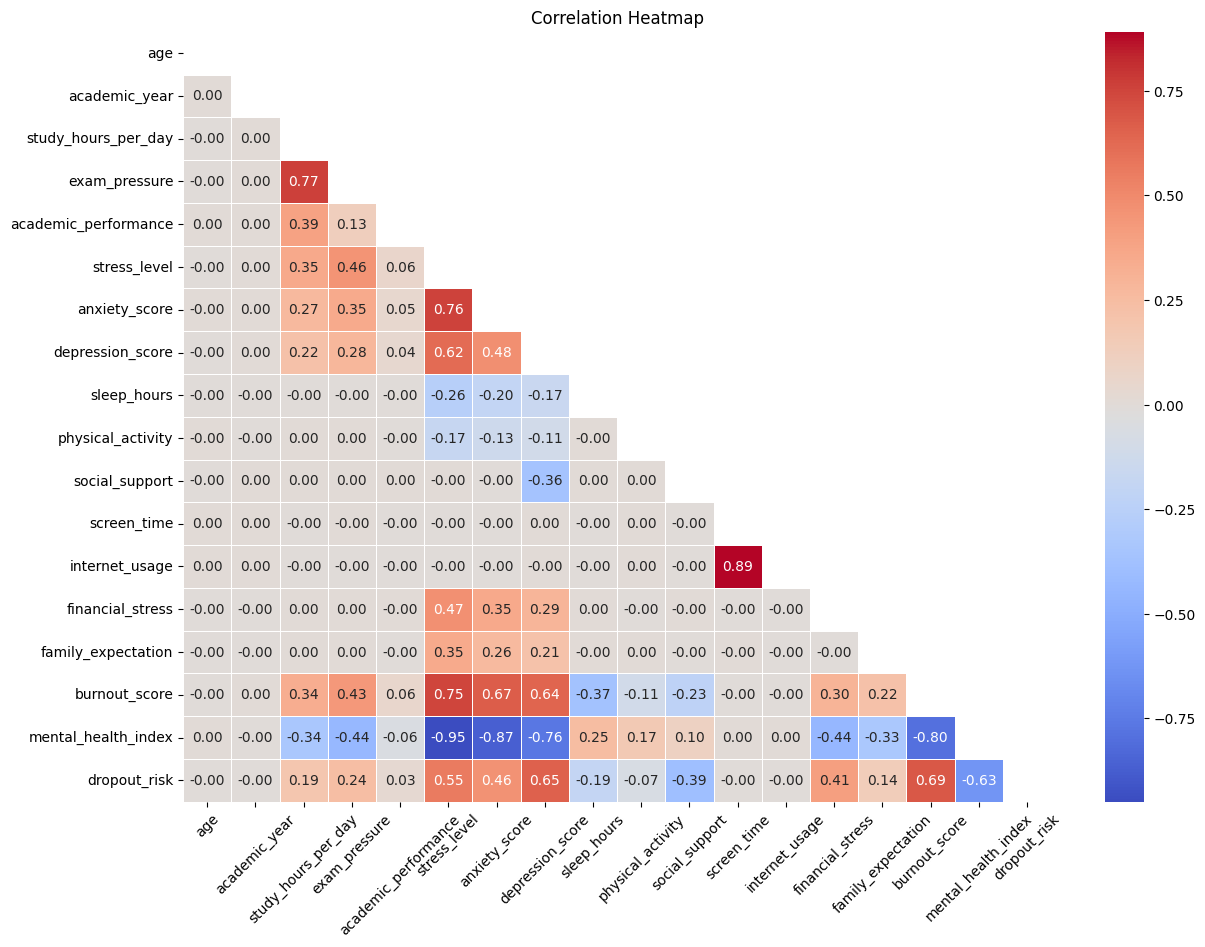

In [13]:
corr = data.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14,10))
sns.heatmap(corr, mask=mask, annot=True,fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [14]:
corr_target = data.corr(numeric_only=True)["burnout_score"].sort_values(ascending=False)

print(corr_target)

burnout_score           1.000000
stress_level            0.753111
dropout_risk            0.689748
anxiety_score           0.668450
depression_score        0.642612
exam_pressure           0.434376
study_hours_per_day     0.335132
financial_stress        0.295702
family_expectation      0.217843
academic_performance    0.057089
academic_year           0.000555
age                    -0.001016
internet_usage         -0.001151
screen_time            -0.001215
physical_activity      -0.110074
social_support         -0.229811
sleep_hours            -0.371386
mental_health_index    -0.796527
Name: burnout_score, dtype: float64


In [15]:
corr_target = data.corr(numeric_only=True)["dropout_risk"].sort_values(ascending=False)

print(corr_target)

dropout_risk            1.000000
burnout_score           0.689748
depression_score        0.654336
stress_level            0.554140
anxiety_score           0.461764
financial_stress        0.406470
exam_pressure           0.243437
study_hours_per_day     0.187382
family_expectation      0.138195
academic_performance    0.032104
screen_time            -0.000959
internet_usage         -0.001100
academic_year          -0.001220
age                    -0.001895
physical_activity      -0.070918
sleep_hours            -0.191171
social_support         -0.394994
mental_health_index    -0.626425
Name: dropout_risk, dtype: float64


In [16]:
corr_target = data.corr(numeric_only=True)["mental_health_index"].sort_values(ascending=False)

print(corr_target)

mental_health_index     1.000000
sleep_hours             0.250408
physical_activity       0.165397
social_support          0.102367
internet_usage          0.001608
screen_time             0.001057
age                     0.000946
academic_year          -0.001332
academic_performance   -0.056318
family_expectation     -0.329124
study_hours_per_day    -0.335030
exam_pressure          -0.435846
financial_stress       -0.443399
dropout_risk           -0.626425
depression_score       -0.763197
burnout_score          -0.796527
anxiety_score          -0.868666
stress_level           -0.949393
Name: mental_health_index, dtype: float64


## **Visualisasi Faktor Akademik terhadap Burnout**

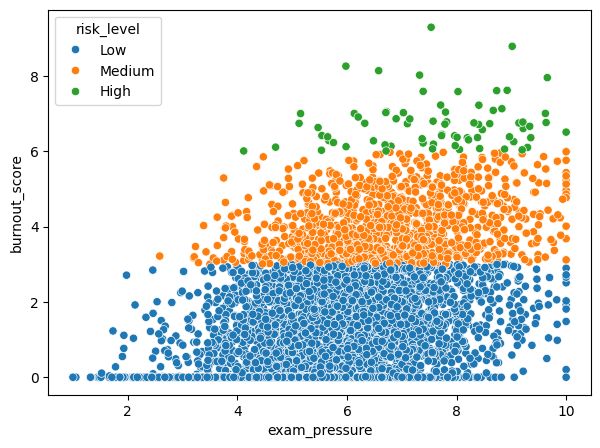

In [17]:
sample_plot=data.sample(5000, random_state=42)
plt.figure(figsize=(7,5))
sns.scatterplot(data=sample_plot, x='exam_pressure', y='burnout_score', hue='risk_level')
plt.show()

# **Sampling**

In [18]:
sampled_data = (
    data.groupby("risk_level", group_keys=False)
    .apply(lambda x: x.sample(frac=0.5, random_state=42))
    .reset_index(drop=True)
)

print("\nShape Setelah Sampling :", sampled_data.shape)

print("\nJumlah Data Tiap Target Setelah Sampling")
print(sampled_data["risk_level"].value_counts())


Shape Setelah Sampling : (500000, 20)

Jumlah Data Tiap Target Setelah Sampling
risk_level
Low       383322
Medium    109138
High        7540
Name: count, dtype: int64


# **Data Leakage**

In [19]:
leakage_features = ["burnout_score", "mental_health_index", "dropout_risk"]

X = sampled_data.drop(columns=leakage_features + ["risk_level"])

y = sampled_data["risk_level"]

# **Preprocessing**

In [20]:
label_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

y_encoded = y.map(label_mapping).astype(int)

print("\nLabel Encoding")
print(label_mapping)


Label Encoding
{'Low': 0, 'Medium': 1, 'High': 2}


# **Train-test Split**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# **Transformation**

In [22]:
categorical_nominal = ["gender"]

categorical_ordinal = ["academic_year"]

numerical_features = [
    col for col in X.columns
    if col not in categorical_nominal + categorical_ordinal
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "gender",
            OneHotEncoder(drop="first"),
            categorical_nominal
        ),
        (
            "academic",
            OrdinalEncoder(categories=[[1, 2, 3, 4]]),
            categorical_ordinal
        )
    ]
)

# **SMOTE**

In [23]:
smote = SMOTE(random_state=42)

# **SVM Baseline**

In [24]:
svm_pipeline = ImbPipeline([

    (
        "preprocessor",
        preprocessor
    ),

    (
        "smote",
        smote
    ),

    (
        "model",

        LinearSVC(
            C=1,
            dual=False,
            loss= "squared_hinge",
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)

print("\nSVM BASELINE")
print(classification_report(y_test, y_pred_svm))


SVM BASELINE
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     76664
           1       0.63      0.45      0.53     21828
           2       0.18      0.92      0.31      1508

    accuracy                           0.82    100000
   macro avg       0.58      0.77      0.58    100000
weighted avg       0.85      0.82      0.83    100000



# **SVM Tunning**

In [25]:
param_svm = {

    "model__C": [0.1, 1, 10],

    "model__loss": [
        "hinge",
        "squared_hinge"
    ],

     "model__max_iter": [1000, 2000, 3000]
}

svm_tuning = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=param_svm,
    n_iter=5,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)

svm_tuning.fit(X_train, y_train)

best_svm = svm_tuning.best_estimator_

y_pred_svm_tuned = best_svm.predict(X_test)

print("\nBEST SVM PARAMETER")
print(svm_tuning.best_params_)

print("\nSVM TUNED")

print(classification_report(y_test, y_pred_svm_tuned))


BEST SVM PARAMETER
{'model__max_iter': 3000, 'model__loss': 'squared_hinge', 'model__C': 0.1}

SVM TUNED
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     76664
           1       0.63      0.45      0.53     21828
           2       0.18      0.92      0.31      1508

    accuracy                           0.82    100000
   macro avg       0.58      0.77      0.58    100000
weighted avg       0.85      0.82      0.83    100000



# **Random Forest Baseline**

In [26]:
rf_pipeline = ImbPipeline([

    (
        "preprocessor",
        preprocessor
    ),

    (
        "smote",
        smote
    ),

    (
        "model",

        RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_leaf=2,
            min_samples_split = 2,
            max_features = "sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        )
    )
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("\nRF BASELINE")

print(classification_report(y_test, y_pred_rf))


RF BASELINE
              precision    recall  f1-score   support

           0       0.95      0.85      0.90     76664
           1       0.59      0.76      0.66     21828
           2       0.37      0.61      0.46      1508

    accuracy                           0.83    100000
   macro avg       0.64      0.74      0.67    100000
weighted avg       0.86      0.83      0.84    100000



# **Random forest Tuning**

In [27]:
param_rf = {

    "model__n_estimators": [100, 200, 300],

    "model__max_depth": [10, 30, None],

    "model__min_samples_leaf": [1, 2, 4],

    "model__min_samples_split": [2, 5, 10],

    "model__max_features": ["sqrt", "log2"]

}

rf_tuning = RandomizedSearchCV(

    estimator=rf_pipeline,

    param_distributions=param_rf,

    n_iter=5,

    cv=3,

    scoring="f1_macro",

    n_jobs=-1,

    random_state=42
)

rf_tuning.fit(X_train, y_train)

best_rf = rf_tuning.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

print("\nBEST RF PARAMETER")
print(rf_tuning.best_params_)

print("\nRF TUNED")

print(classification_report(y_test, y_pred_rf_tuned))


BEST RF PARAMETER
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 30}

RF TUNED
              precision    recall  f1-score   support

           0       0.94      0.87      0.90     76664
           1       0.60      0.76      0.67     21828
           2       0.41      0.57      0.48      1508

    accuracy                           0.84    100000
   macro avg       0.65      0.73      0.68    100000
weighted avg       0.86      0.84      0.85    100000



## **Confusion Matrix**

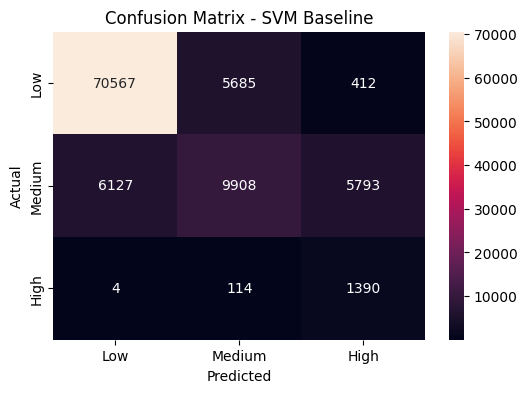

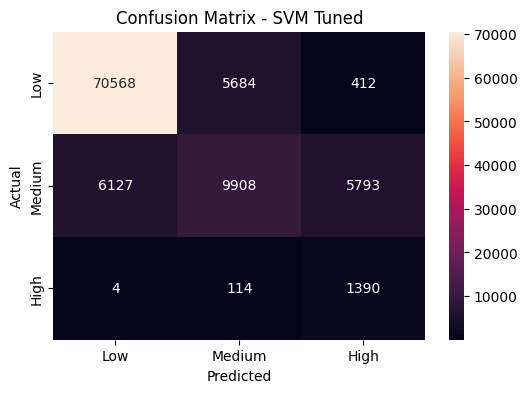

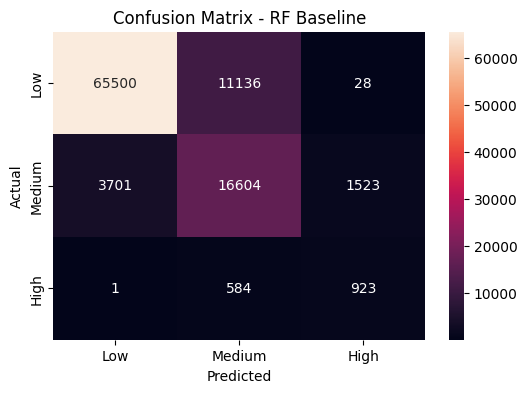

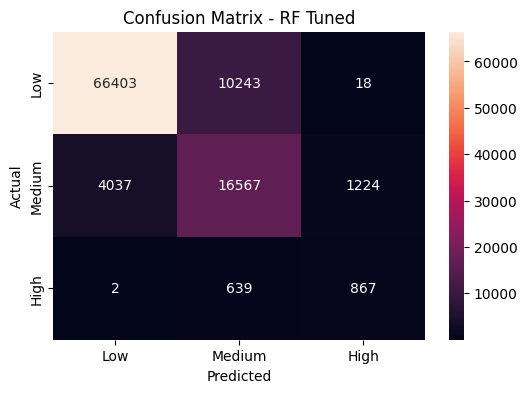

In [28]:
models = [
    ("SVM Baseline", y_pred_svm),
    ("SVM Tuned", y_pred_svm_tuned),
    ("RF Baseline", y_pred_rf),
    ("RF Tuned", y_pred_rf_tuned)
]

labels = ["Low", "Medium", "High"]

for title, pred in models:
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# **LEARNING CURVE - SVM**

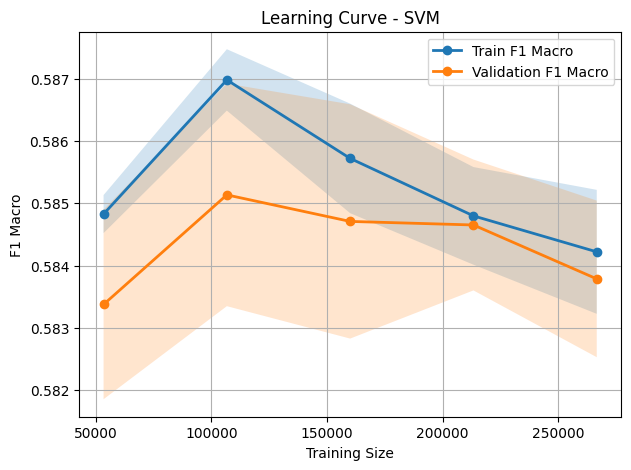

In [29]:
train_sizes, train_scores, val_scores = learning_curve(

    estimator=best_svm,

    X=X_train,

    y=y_train,

    cv=3,

    scoring="f1_macro",

    train_sizes=np.linspace(0.2, 1.0, 5),

    n_jobs=-1

)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(7,5))

# TRAIN LINE
plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    linewidth=2,
    label="Train F1 Macro"
)

# VALIDATION LINE
plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    linewidth=2,
    label="Validation F1 Macro"
)

# TRAIN AREA
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

# VALIDATION AREA
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.title("Learning Curve - SVM")

plt.xlabel("Training Size")
plt.ylabel("F1 Macro")

plt.legend()

plt.grid()

plt.show()

# **LEARNING CURVE - RANDOM FOREST**

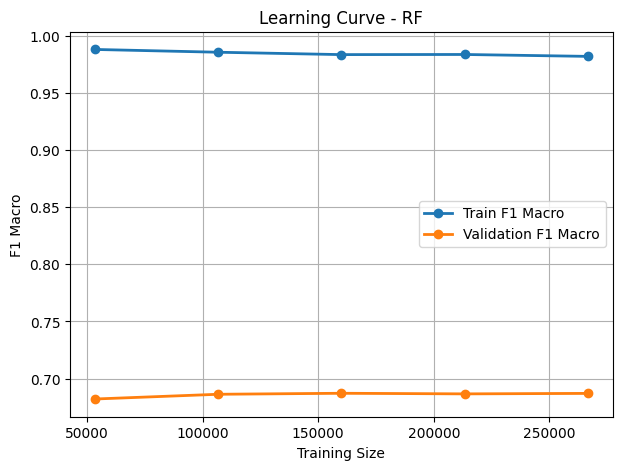

In [30]:
train_sizes, train_scores, val_scores = learning_curve(

    estimator=best_rf,

    X=X_train,

    y=y_train,

    cv=3,

    scoring="f1_macro",

    train_sizes=np.linspace(0.2, 1.0, 5),

    n_jobs=-1

)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(7,5))

# TRAIN LINE
plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    linewidth=2,
    label="Train F1 Macro"
)

# VALIDATION LINE
plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    linewidth=2,
    label="Validation F1 Macro"
)

# TRAIN AREA
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

# VALIDATION AREA
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.title("Learning Curve - RF")

plt.xlabel("Training Size")
plt.ylabel("F1 Macro")

plt.legend()

plt.grid()

plt.show()

# **Feature Importance**

# Random forest

In [31]:
rf_model = best_rf.named_steps["model"]

preprocessor_fitted = best_rf.named_steps["preprocessor"]

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Top 10 fitur


TOP FEATURE IMPORTANCE


,Feature,Importance
4,num__stress_level,0.253468
5,num__anxiety_score,0.154295
6,num__depression_score,0.138115
7,num__sleep_hours,0.077036
2,num__exam_pressure,0.060863
9,num__social_support,0.059550
1,num__study_hours_per_day,0.037226
12,num__financial_stress,0.033931
13,num__family_expectation,0.028622
8,num__physical_activity,0.027181


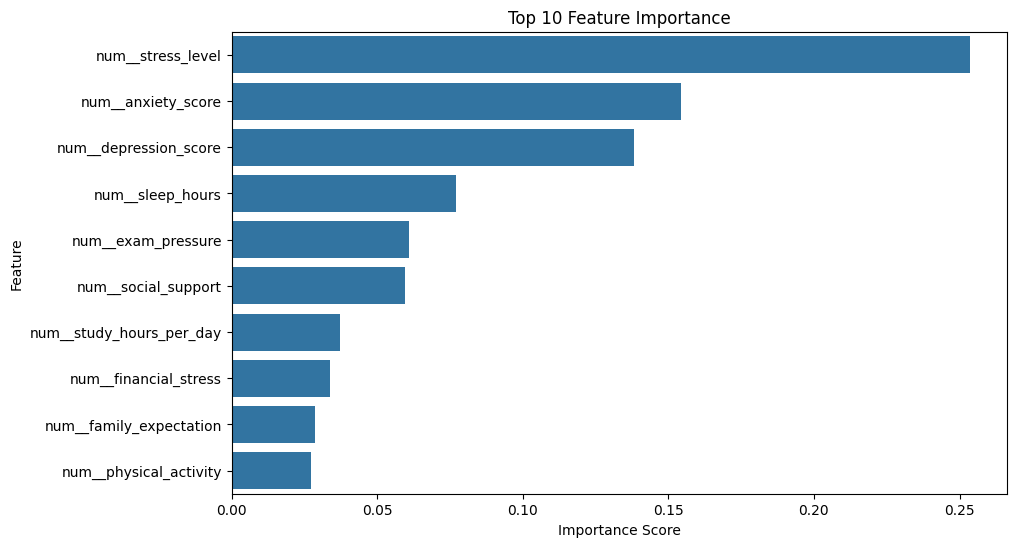

In [32]:
print("\nTOP FEATURE IMPORTANCE")
display(importance_df.head(10))

top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# SVM

In [33]:
svm_model = best_svm.named_steps["model"]

feature_names = (
    best_svm.named_steps["preprocessor"]
    .get_feature_names_out()
)

coef = np.abs(svm_model.coef_).mean(axis=0)

svm_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coef
})

svm_importance = svm_importance.sort_values(
    by="Importance",
    ascending=False
)

# Top 10 Fitur


TOP FEATURE IMPORTANCE


,Feature,Importance
4,num__stress_level,0.447513
9,num__social_support,0.216254
7,num__sleep_hours,0.214271
5,num__anxiety_score,0.211105
2,num__exam_pressure,0.147335
6,num__depression_score,0.131873
15,gender__gender_Other,0.093569
11,num__internet_usage,0.019979
12,num__financial_stress,0.016566
10,num__screen_time,0.015417


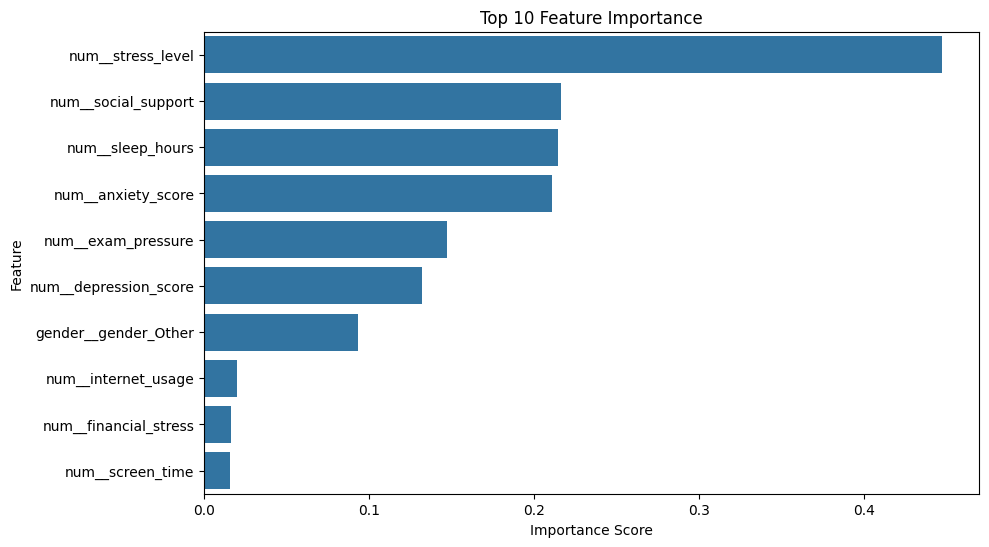

In [34]:
print("\nTOP FEATURE IMPORTANCE")
display(svm_importance.head(10))

top_features = svm_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# **Comparison**

In [35]:
from sklearn.metrics import precision_score, recall_score

comparison_table = pd.DataFrame({

    "Model": [
        "SVM Baseline",
        "SVM Tuned",
        "RF Baseline",
        "RF Tuned"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_svm_tuned),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],

    "Precision Macro": [
        precision_score(y_test, y_pred_svm, average="macro"),
        precision_score(y_test, y_pred_svm_tuned, average="macro"),
        precision_score(y_test, y_pred_rf, average="macro"),
        precision_score(y_test, y_pred_rf_tuned, average="macro")
    ],

    "Recall Macro": [
        recall_score(y_test, y_pred_svm, average="macro"),
        recall_score(y_test, y_pred_svm_tuned, average="macro"),
        recall_score(y_test, y_pred_rf, average="macro"),
        recall_score(y_test, y_pred_rf_tuned, average="macro")
    ],

    "F1 Macro": [
        f1_score(y_test, y_pred_svm, average="macro"),
        f1_score(y_test, y_pred_svm_tuned, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_rf_tuned, average="macro")
    ],

    "Recall High": [
        recall_score(y_test, y_pred_svm, labels=[2], average="macro"),
        recall_score(y_test, y_pred_svm_tuned, labels=[2], average="macro"),
        recall_score(y_test, y_pred_rf, labels=[2], average="macro"),
        recall_score(y_test, y_pred_rf_tuned, labels=[2], average="macro")
    ]
})

comparison_table

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Recall High
0,SVM Baseline,0.81865,0.577960,0.765378,0.584532,0.921751
1,SVM Tuned,0.81866,0.577974,0.765382,0.584539,0.921751
2,RF Baseline,0.83027,0.635267,0.742374,0.674606,0.612069
3,RF Tuned,0.83837,0.652438,0.733356,0.684866,0.574934


# **Hasil Prediksi**

In [36]:
label_map = {
    0: "Low",
    1: "Medium",
    2: "High"
}

df_pred = pd.DataFrame({
    "Actual": y_test,
    "SVM Baseline": y_pred_svm,
    "SVM Tuned": y_pred_svm_tuned,
    "RF Baseline": y_pred_rf,
    "RF Tuned": y_pred_rf_tuned
})

for col in df_pred.columns:
    df_pred[col] = df_pred[col].map(label_map)

df_pred.head(10)

,Actual,SVM Baseline,SVM Tuned,RF Baseline,RF Tuned
77038,Low,Low,Low,Low,Low
454208,Medium,Low,Low,Medium,Medium
474868,Medium,Low,Low,Medium,Medium
73093,Low,Medium,Medium,Medium,Medium
312378,Low,Low,Low,Low,Low
163326,Low,Low,Low,Low,Low
83958,Low,Low,Low,Low,Low
66612,Low,Low,Low,Low,Low
282523,Low,Low,Low,Low,Low
268860,Low,Low,Low,Low,Low
